In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
import re

def extract_maxerr(log_file_path):
    """
    Extract the maxerr value from a log file.
    
    Args:
        log_file_path: Path to the log file
        
    Returns:
        float: The maxerr value, or None if not found
    """
    pattern = r'maxerr\s*=\s*([\d.eE+-]+)'
    
    with open(log_file_path, 'r') as f:
        # Read from the end of the file for efficiency
        lines = f.readlines()
        
        # Search backwards through the last ~20 lines
        for line in reversed(lines[-20:]):
            match = re.search(pattern, line)
            if match:
                return float(match.group(1))
    
    return None

In [3]:
def extract_velocity(velocity_file_path):
    """
    Extract the velocity data from a .npz file.
    
    Args:
        velocity_file_path: Path to the .npz file
    Returns:
        np.ndarray: The velocity data, or None if not found
        maxerr: The maxerr value extracted from the corresponding log file
    """
    if not os.path.exists(velocity_file_path):
        print(f"Velocity file {velocity_file_path} does not exist.")
        return None, None
    
    velocity_data = np.load(velocity_file_path)['drift3d']
    
    # Construct the corresponding log file path
    log_file_path = '/'.join(velocity_file_path.split('/')[:-2]) + '/pochoir.log'
    
    maxerr = extract_maxerr(log_file_path)
    
    # get efield
    path_to_efield = '/'.join(velocity_file_path.split('/')[:-2]) + '/velocity/efield.npz'
    efield = np.load(path_to_efield)['efield']/1e-6
    return velocity_data, maxerr, efield

In [4]:
list_steps = [1300, 2600, 3900, 5000, 10000, 50_000, 100_000]
list_steps = [100_000, 500_000, '1M']
# list_steps = [500_000, '1M']

In [5]:
speed_unit = 0.001

efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 1.69e-03
efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 5.59e-05
efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 8.33e-07


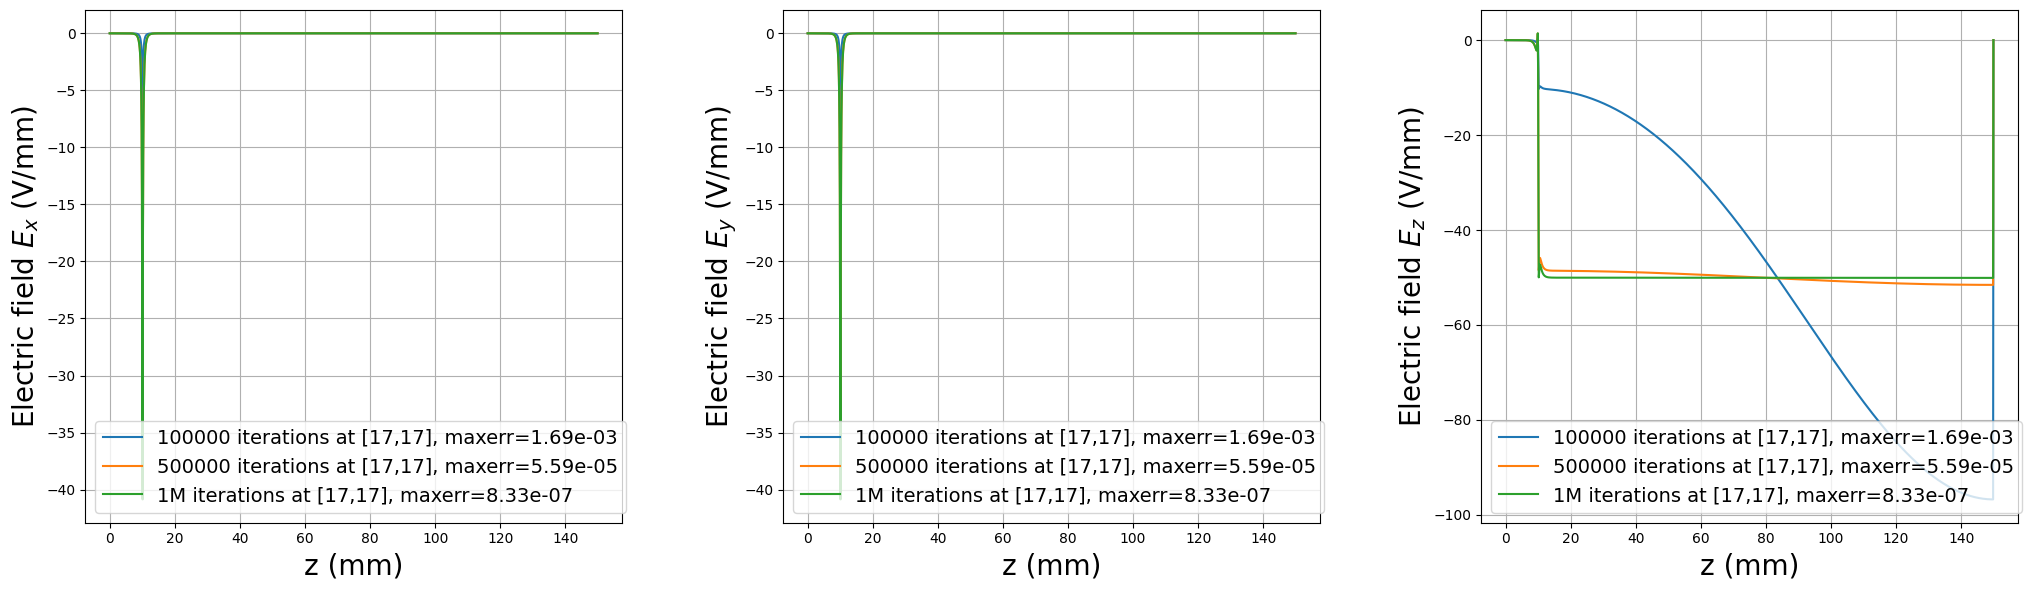

In [25]:
list_velocities = []
for steps in list_steps:
    path_to_velocity_file = f'../store_{steps}steps/velocity/drift3d.npz'
    velocity_data, maxerr, efield = extract_velocity(path_to_velocity_file)
    list_velocities.append((velocity_data, maxerr, efield))
for i, (velocity_data, maxerr, efield) in enumerate(list_velocities):
    print(f'efield shape: {efield.shape}, velocity shape: {velocity_data.shape}, maxerr: {maxerr:.2e}')
# plt.figure(figsize=(10, 6))
axes  = ['x', 'y', 'z']
fig, ax = plt.subplots(1,3, figsize=(21, 6))
for j in range(3):
    for i, (velocity_data, maxerr, efield) in enumerate(list_velocities):
        # ax[j].plot(np.arange(velocity_data.shape[3])*0.1, velocity_data[j, 17,17,:]/speed_unit, label=f'{list_steps[i]} iterations at [17,17], maxerr={maxerr:.2e}')
        ax[j].plot(np.arange(efield.shape[3])*0.1, efield[j, 17,17,:], label=f'{list_steps[i]} iterations at [17,17], maxerr={maxerr:.2e}')
    ax[j].set_xlabel('z (mm)', fontsize=20)
    # ax[j].set_ylabel(f'Drift velocity $v_{axes[j]}$ (mm/us)', fontsize=20)
    ax[j].set_ylabel(f'Electric field $E_{axes[j]}$ (V/mm)', fontsize=20)
    ax[j].grid(True)
    # ax[j].set_ylabel('Electric field $E_z$ (V/mm)', fontsize=20)
    # ax[j].set_xticks(fontsize=20)
    # ax[j].set_xticks(fontsize=20)
    # ax[j].set_yticks(fontsize=20)
    ax[j].legend(fontsize=14)
# plt.ylim([0, -100])
plt.tight_layout()
plt.show()

In [72]:
v0 = np.load('../store/velocity/efield.npz')['efield']
# v1 = np.load('../store_1Msteps_allFloat64_torchCompile/velocity/drift3d.npz')['drift3d']
# v2 = np.load('../store_1Msteps_allFloat32/velocity/efield.npz')['efield']
# v3 = np.load('../store_1Msteps_allFloat32_nonZeroArr/velocity/efield.npz')['efield']
# v4 = np.load('../store_10000steps/velocity/drift3d.npz')['drift3d']

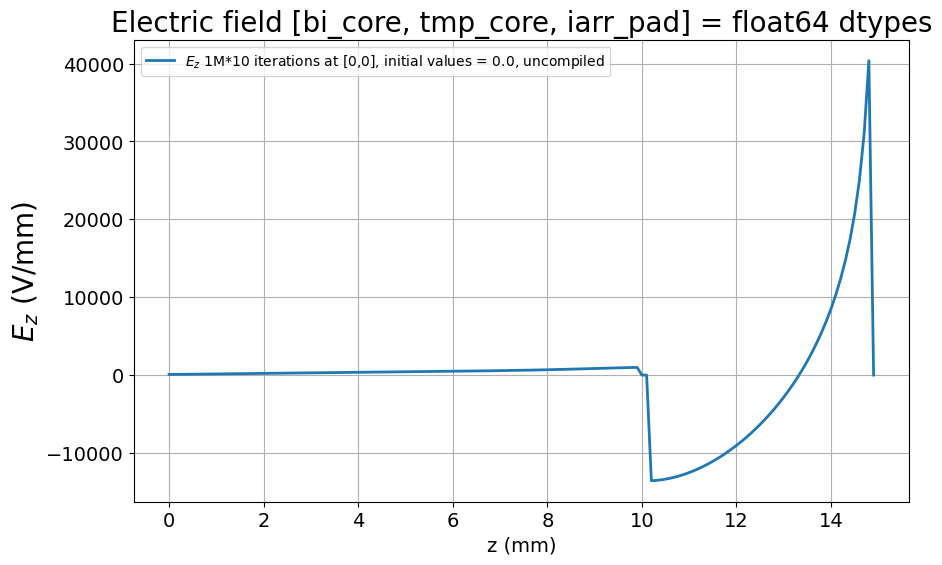

In [73]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(v0.shape[3])*0.1, v0[2, 0,0,:]/1e-6, linewidth=2,label=r'$E_z$ 1M*10 iterations at [0,0], initial values = 0.0, uncompiled')
# plt.plot(np.arange(v1.shape[3])*0.1, v1[2, 0,0,:]/1e-6, label=r'$E_z$ 1M*10 iterations at [0,0], initial values : linear along z')
# plt.plot(np.arange(v1.shape[3])*0.1, v1[2, 0,0,:]/1e-6, label=r'$E_z$ 1M*10 iterations at [0,0], initial values : 0.0, compiled')
# plt.plot(np.arange(v2.shape[3])*0.1, v2[2, 0,0,:]/1e-6, 'c--', label=r'$E_z$ 1M*10 iterations at [0,0], [float32, float32, float32]')
# plt.plot(np.arange(v3.shape[3])*0.1, v3[2, 0,0,:]/1e-6, 'm--', label=r'$E_z$ 1M*10 iterations at [0,0], [float32, float32, float32, non zero iarr]')
# plt.plot(np.arange(v2.shape[3])*0.1, v2[2, 0,0,:], label=r'$v_z$ 3900 iterations at [0,0]')
# plt.plot(np.arange(v3.shape[3])*0.1, v3[2, 0,0,:], label=r'$v_z$ 5000 iterations at [0,0]')
# plt.plot(np.arange(v4.shape[3])*0.1, v4[2, 0,0,:], label=r'$v_z$ 10000 iterations at [0,0]')
plt.xlabel('z (mm)', fontsize=14)
plt.ylabel(r'$E_z$ (V/mm)', fontsize=20)
plt.title("Electric field [bi_core, tmp_core, iarr_pad] = float64 dtypes", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim([7,12])
plt.grid(True)
plt.legend()

In [41]:
path_to_inital_values = '../store/initial/drift3d.npz'
iarr = np.load(path_to_inital_values)['drift3d']
print(f'iarr shape: {iarr.shape}, iarr dtype: {iarr.dtype}')

iarr shape: (44, 44, 1500), iarr dtype: float64


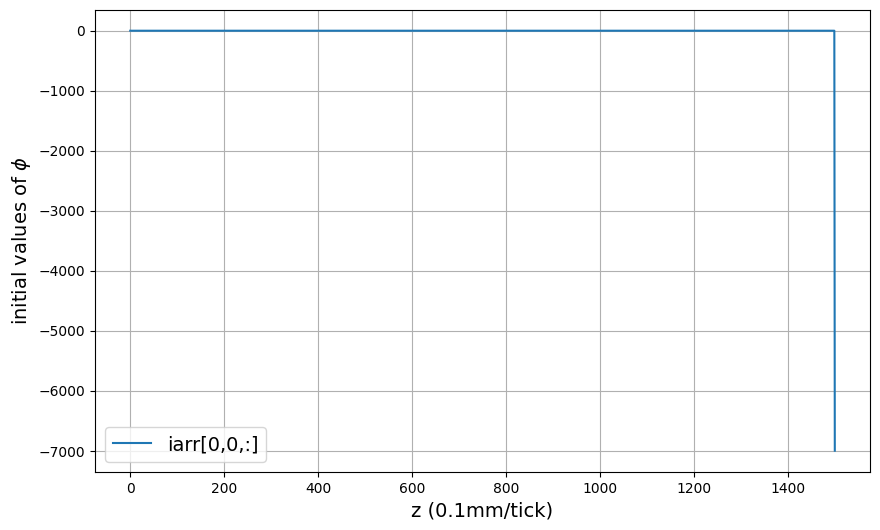

In [42]:
plt.figure(figsize=(10, 6))
# for i in range(5):
#     plt.plot(np.arange(iarr.shape[2]), iarr[i, i,:], label=f'iarr[{i},{i},:]')
plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'iarr[0,0,:]')
plt.xlabel('z (0.1mm/tick)', fontsize=14)
plt.ylabel(r'initial values of $\phi$', fontsize=14)
plt.grid(True)
# plt.xlim(0, 200)
# plt.ylim(-200, 1)
plt.legend(fontsize=14)
plt.show()


In [94]:
potential_file_path = '../store/potential/drift3d.npz'
potential = np.load(potential_file_path)['drift3d']
print(f'potential shape: {potential.shape}, potential dtype: {potential.dtype}')

potential shape: (44, 44, 150), potential dtype: float64


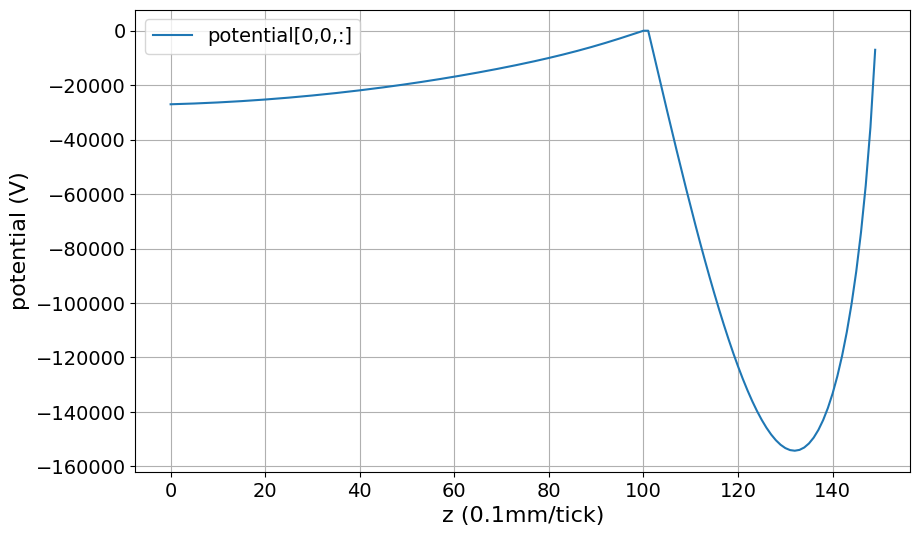

In [95]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(potential.shape[2]), potential[0,0,:], label='potential[0,0,:]')
# plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'iarr[0,0,:]')
plt.xlabel('z (0.1mm/tick)', fontsize=16)
plt.ylabel('potential (V)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.xlim(1498, 1500)
# plt.ylim(-1000, 10)
plt.show()

['drift3d.npz', 'drift3d_epoch0.npz', 'drift3d_epoch1.npz', 'drift3d_epoch2.npz', 'drift3d_epoch3.npz', 'drift3d_epoch4.npz', 'drift3d_epoch5.npz', 'drift3d_epoch6.npz', 'drift3d_epoch7.npz', 'drift3d_epoch8.npz', 'drift3d_epoch9.npz']


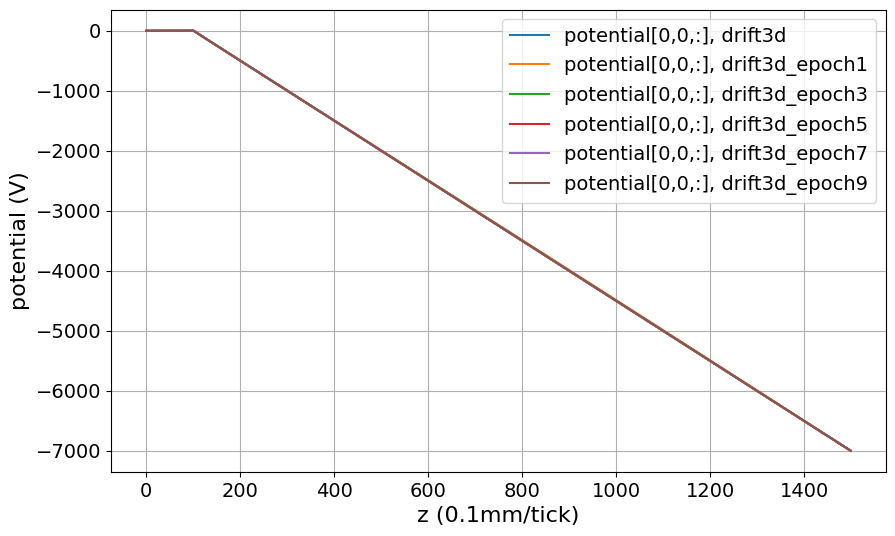

In [34]:
list_potentials = [f for f in os.listdir('../store/potential') if f.endswith('.npz')]
list_potentials.sort()
print(list_potentials)
plt.figure(figsize=(10, 6))
for i, f in enumerate(list_potentials):
    if i%2!=0:
        continue
    potential_file_path = os.path.join('../store/potential', f)
    potential = np.load(potential_file_path)[f.split('/')[-1].split('.')[0]]
    plt.plot(np.arange(potential.shape[2]), potential[0,0,:], label=f'potential[0,0,:], {f.split("/")[-1].split(".")[0]}')
plt.xlabel('z (0.1mm/tick)', fontsize=16)
plt.ylabel('potential (V)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim()
plt.grid(True)
plt.legend(fontsize=14)
plt.show()

In [28]:

path_to_err = '../store/increment/drift3d.npz'
err_data = np.load(path_to_err)['drift3d']


2026-03-08 23:59:37,146 - root - INFO - using FDM engine torch
2026-03-08 23:59:37,454 - root - INFO - bi_core shape = torch.Size([44, 44, 1500]), mutable_core shape = torch.Size([44, 44, 1500]), tmp_core shape = torch.Size([44, 44, 1500]), 
	iarr_pad_shape = torch.Size([46, 46, 1502])
2026-03-08 23:59:37,454 - root - INFO - bi_core device = cuda:1, mutable_core device = cuda:1, tmp_core device = cuda:1, 
	iarr_pad_device = cuda:1
2026-03-08 23:59:37,454 - root - INFO - bi_core dtype = torch.float32, mutable_core dtype = torch.float32, tmp_core dtype = torch.float32, 
	iarr_pad_dtype = torch.float32
2026-03-08 23:59:37,454 - root - INFO - PYTHON OVERHEAD : FOR Loops
2026-03-08 23:59:37,454 - root - INFO - ====== epoch: 0/10 x 1000000 ===============
2026-03-09 00:00:54,749 - root - INFO - epoch 0 time: 77.30 seconds
2026-03-09 00:00:54,749 - root - INFO - ====== epoch: 1/10 x 1000000 ===============
2026-03-09 00:02:09,954 - root - INFO - epoch 1 time: 75.20 seconds
2026-03-09 00:02:09

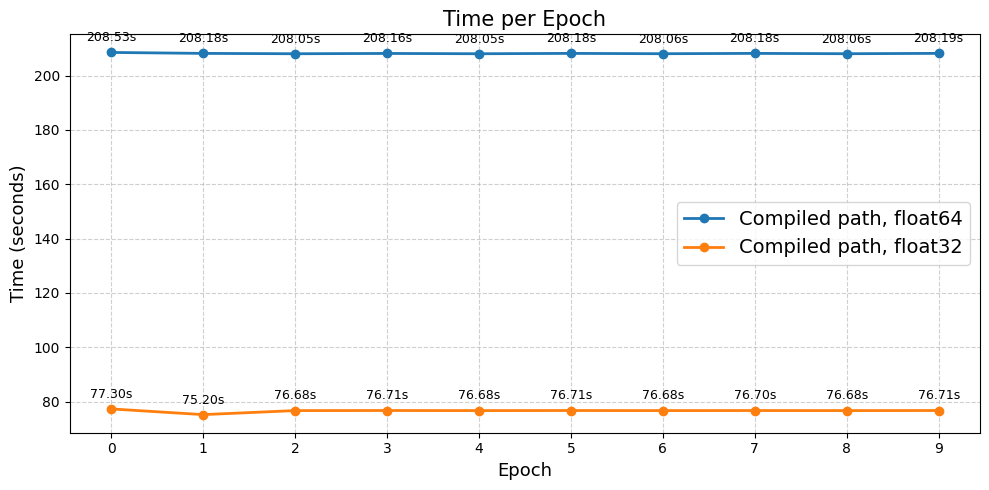

In [15]:


import re
import sys
import matplotlib.pyplot as plt

def parse_epoch_times(log_text):
    pattern = r"epoch (\d+) time: ([\d.]+) seconds"
    matches = re.findall(pattern, log_text)
    epochs = [int(m[0]) for m in matches]
    times = [float(m[1]) for m in matches]
    return epochs, times

def plot_epoch_times(fig, ax, epochs, times, label):
    # fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, times, marker='o', linewidth=2, markersize=6, label=label)
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("Time (seconds)", fontsize=13)
    ax.set_title("Time per Epoch", fontsize=15)
    ax.set_xticks(epochs)
    ax.grid(True, linestyle='--', alpha=0.6)

    for e, t in zip(epochs, times):
        ax.annotate(f"{t:.2f}s", (e, t), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=9)

    # plt.tight_layout()
    # plt.savefig("epoch_times.png", dpi=150)
    # print("Plot saved to epoch_times.png")
    # plt.show()

with open('../store_1Msteps_allFloat32_torchCompile/pochoir.log', "r") as f:
    log_text = f.read()
print(log_text)
epochs, times = parse_epoch_times(log_text)

with open('../store_1Msteps_allFloat64_torchCompile/pochoir.log', "r") as f:
    log_text_ = f.read()
print(log_text_)
epochs_, times_ = parse_epoch_times(log_text_)
# if not epochs:
#     print("No epoch time entries found in the log.")
#     sys.exit(1)

print(f"Found {len(epochs)} epochs:")
for e, t in zip(epochs, times):
    print(f"  Epoch {e}: {t:.2f} seconds")

# plot_epoch_times(epochs, times)
fig, ax = plt.subplots(figsize=(10, 5))
plot_epoch_times(fig, ax, epochs_, times_, label='Compiled path, float64')
plot_epoch_times(fig, ax, epochs, times, label='Compiled path, float32')
# ax.set_ylim([205, 250])
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

## plottting the initial values for the weighting field

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def draw_weight3d(path_to_weight, z_index, showerr=False):
    weight3d = np.load(path_to_weight)['weight3d']
    print(f'weight3d shape: {weight3d.shape}, weight3d dtype: {weight3d.dtype}')
    if showerr:
        weighterr_path = None
        splitted_path = path_to_weight.split('/')
        splitted_path[2] = 'increment'
        weighterr_path = '/'.join(splitted_path)
        # try:
        #     weighterr_path = path_to_weight.replace('initial', 'increment')
        # except:
        #     weighterr_path = path_to_weight.replace('potential', 'increment')
        weighterr = np.load(weighterr_path)['weight3d']
        maxerr = np.max(np.abs(weighterr))
        print(f'maxerr: {maxerr:.2e}, path to err: {weighterr_path}')
    
    # make a 2d plot of weight3d[:,:, z_index]
    plt.figure(figsize=(10, 6))
    plt.imshow(weight3d[:,:, z_index], cmap='viridis')
    plt.colorbar(label=f'weight3d[:,:, {z_index}]')
    plt.title(f'2D plot of weight3d[:,:, {z_index}]', fontsize=16)
    plt.xlabel('x index', fontsize=14)
    plt.ylabel('y index', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(False)
    plt.show()

weight3d shape: (220, 220, 1500), weight3d dtype: float64


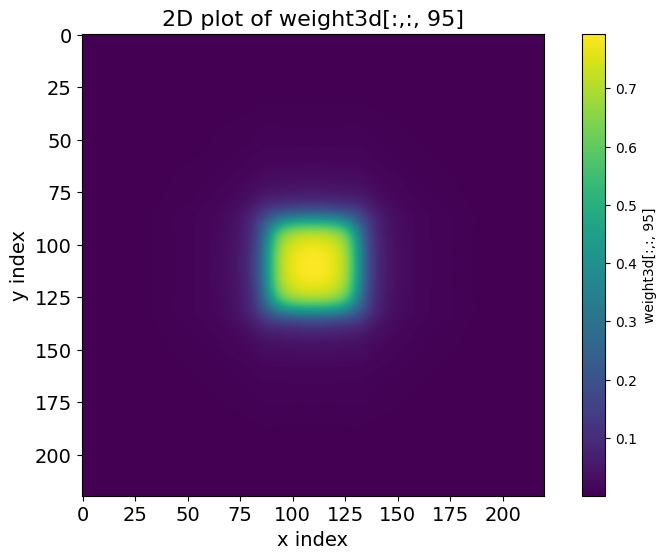

In [2]:
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=95)

weight3d shape: (220, 220, 1500), weight3d dtype: float64


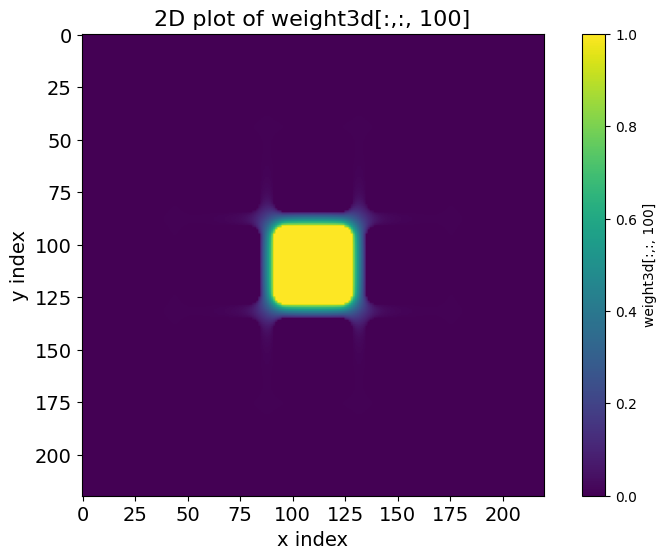

In [3]:
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=100)

weight3d shape: (220, 220, 1500), weight3d dtype: float64


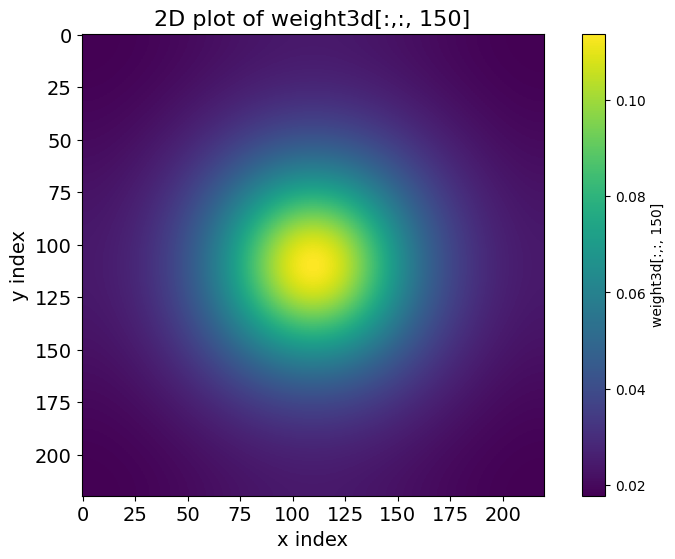

In [4]:
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=150)

In [5]:
## plot weight3d in 3d 
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
weight3d = np.load(path_to_weight)['weight3d']

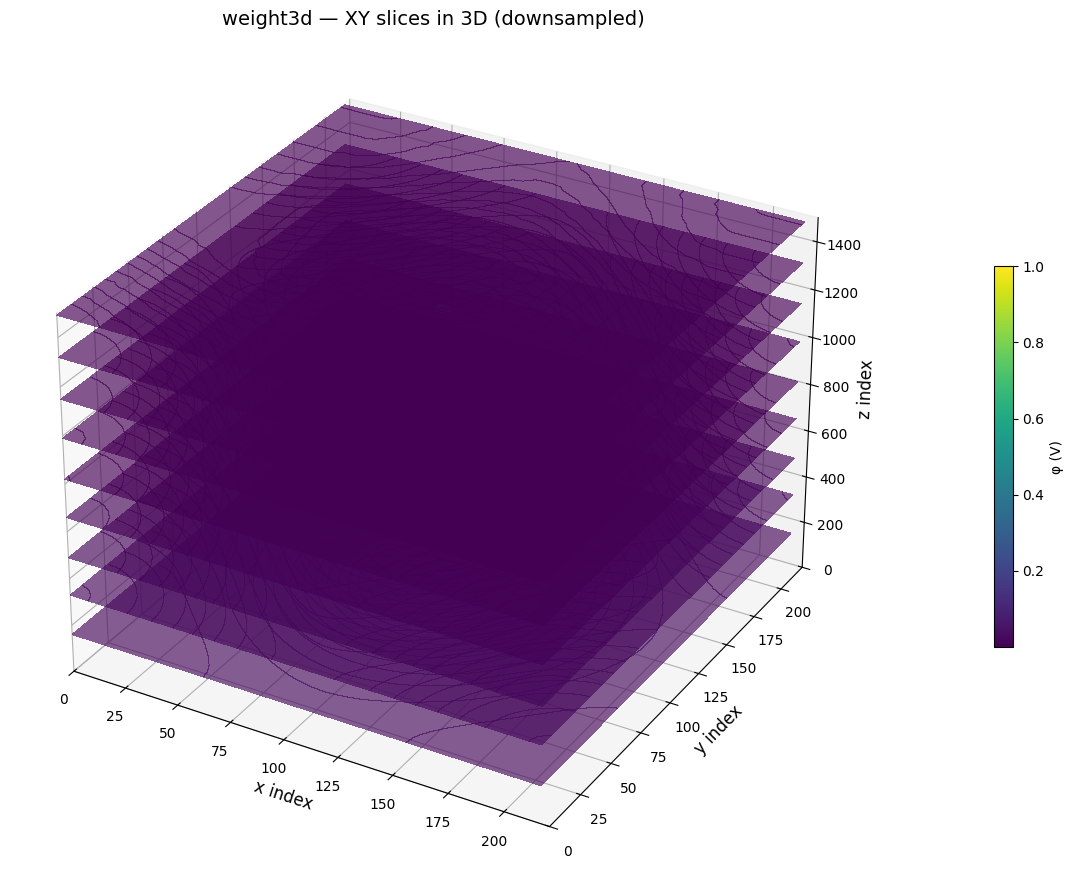

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy.ma as ma

# Downsample to keep rendering fast
step_xy = 4   # every 4th pixel in x/y  → 55×55 per slice
step_z  = 10  # every 10th slice in z

w = weight3d[::step_xy, ::step_xy, ::step_z]
nx, ny, nz = w.shape

x = np.arange(nx) * step_xy
y = np.arange(ny) * step_xy
z = np.arange(nz) * step_z

X, Y = np.meshgrid(x, y, indexing='ij')

vmin, vmax = float(w[w != 0].min()), float(w.max())
cmap = 'viridis'
n_slices = min(10, nz)
z_indices = np.linspace(0, nz - 1, n_slices, dtype=int)

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

for iz in z_indices:
    slice_data = ma.masked_where(np.abs(w[:, :, iz]) < 1e-10, w[:, :, iz])
    ax.contourf(X, Y, slice_data,
                zdir='z', offset=int(z[iz]),
                cmap=cmap, vmin=vmin, vmax=vmax,
                levels=20, alpha=0.65)

ax.set_xlim(0, weight3d.shape[0])
ax.set_ylim(0, weight3d.shape[1])
ax.set_zlim(0, weight3d.shape[2])
ax.set_xlabel('x index', fontsize=12)
ax.set_ylabel('y index', fontsize=12)
ax.set_zlabel('z index', fontsize=12)
ax.set_title('weight3d — XY slices in 3D (downsampled)', fontsize=14)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.1, label='φ (V)')

plt.tight_layout()
plt.show()

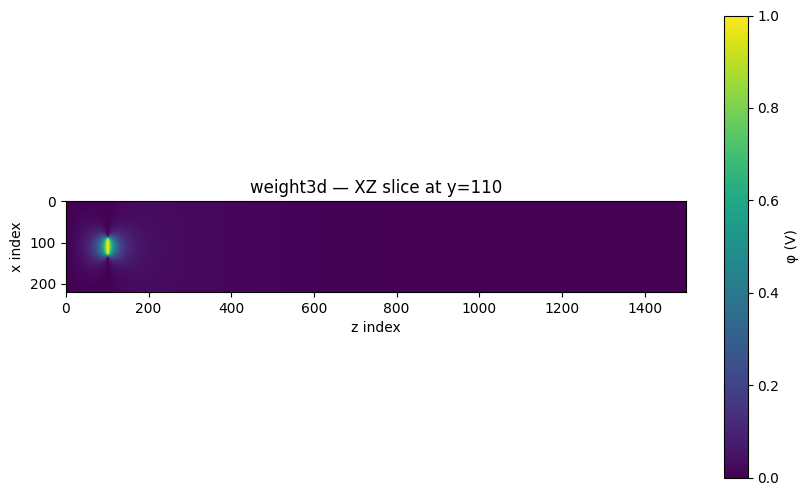

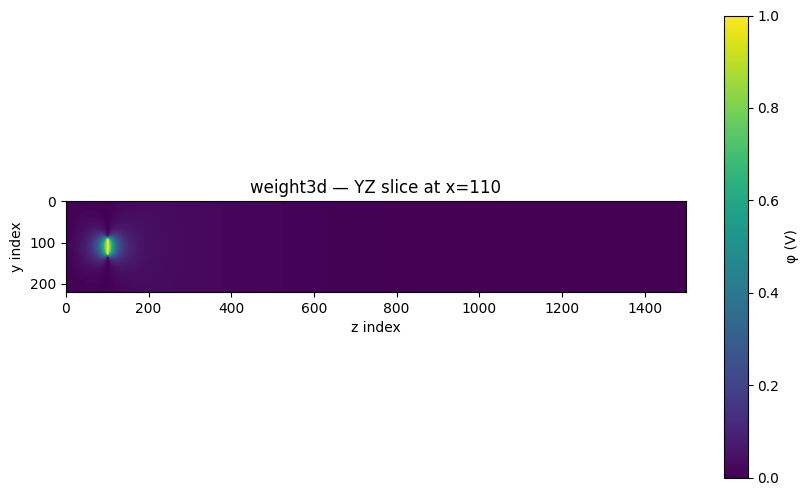

In [22]:
plt.figure(figsize=(10, 6))
plt.imshow(weight3d[:, 110, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('x index')
plt.title('weight3d — XZ slice at y=110')
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(weight3d[110, :, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('y index')
plt.title('weight3d — YZ slice at x=110')
plt.show()

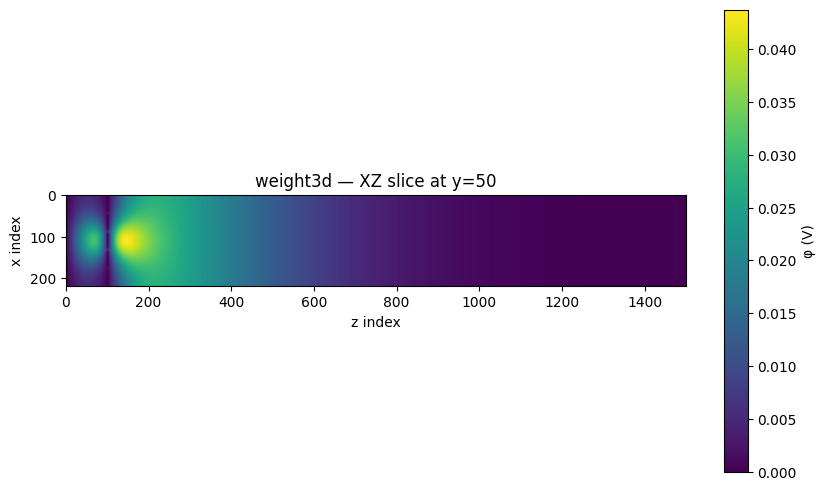

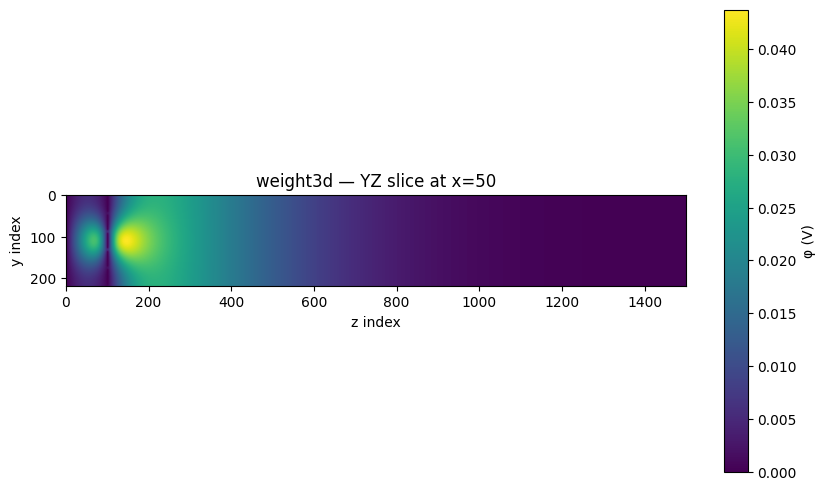

In [23]:
plt.figure(figsize=(10, 6))
plt.imshow(weight3d[:, 50, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('x index')
plt.title('weight3d — XZ slice at y=50')
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(weight3d[50, :, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('y index')
plt.title('weight3d — YZ slice at x=50')
plt.show()

weight3d shape: (220, 220, 1500), weight3d dtype: float64
maxerr: 1.19e-07, path to err: ../store_ok_driftsteps13000000_wsteps500000_pix5x5/increment/weight3d.npz


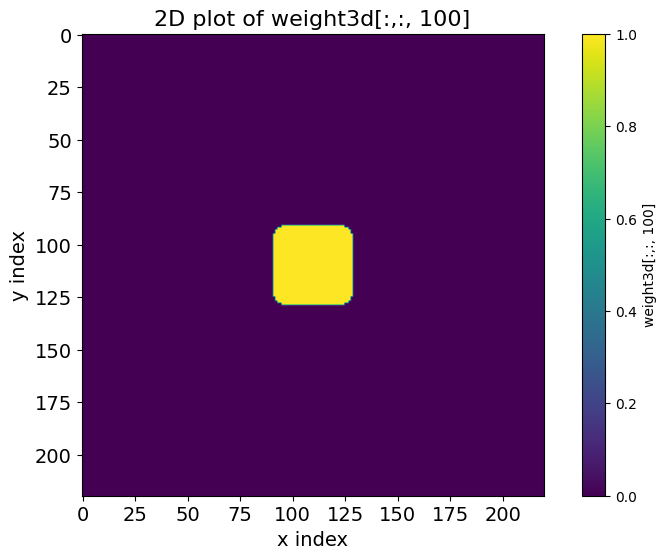

In [2]:
path_to_weight = '../store_ok_driftsteps13000000_wsteps500000_pix5x5/initial/weight3d.npz'
draw_weight3d(path_to_weight, z_index=100, showerr=True)

weight3d shape: (220, 220, 1500), weight3d dtype: float64
maxerr: 1.79e-07, path to err: ../store_ok_driftsteps1300000_wsteps1000000_pix5x5/increment/weight3d.npz


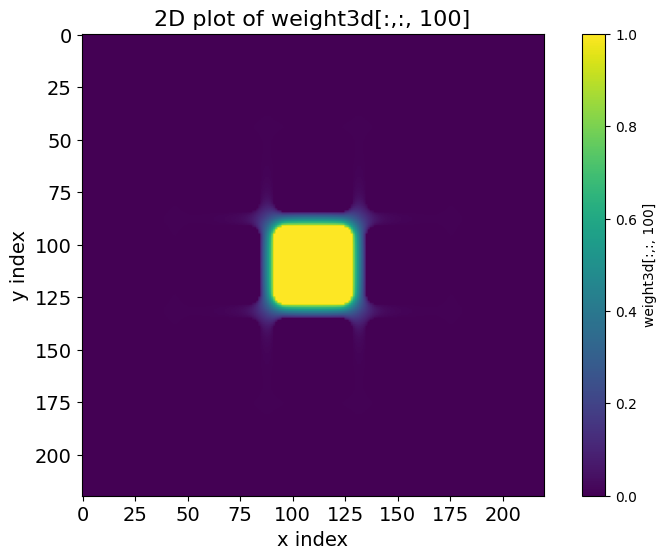

In [25]:
path_to_weight = '../store_ok_driftsteps1300000_wsteps1000000_pix5x5/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=100, showerr=True)

In [27]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

def laplacian_3d_conv(f):
    """
    f: shape (D, H, W) — e.g. torch.Size([46, 46, 152])
    """
    # conv3d expects (B, C, D, H, W) — add both dims temporarily
    x = f.unsqueeze(0).unsqueeze(0)  # → (1, 1, 46, 46, 152)

    kernel = torch.zeros(1, 1, 3, 3, 3, dtype=f.dtype, device=f.device)
    kernel[0, 0, 1, 1, 0] = 1   # z-
    kernel[0, 0, 1, 1, 2] = 1   # z+
    kernel[0, 0, 1, 0, 1] = 1   # y-
    kernel[0, 0, 1, 2, 1] = 1   # y+
    kernel[0, 0, 0, 1, 1] = 1   # x-
    kernel[0, 0, 2, 1, 1] = 1   # x+
    kernel[0, 0, 1, 1, 1] = -6  # center

    out = F.conv3d(x, kernel, padding=1)  # → (1, 1, 46, 46, 152)
    return out.squeeze(0).squeeze(0)      # → (46, 46, 152)

def plot_laplacian_3d(lap: torch.Tensor, n_slices: int = 5):
    """
    lap: shape (D, H, W) — the Laplacian tensor
    n_slices: how many evenly-spaced slices to show per axis
    """
    data = lap.detach().cpu().numpy()
    D, H, W = data.shape

    # Symmetric colormap centered on 0, driven by the true max abs value
    vmax = np.abs(data).max()
    vmin = -vmax

    slice_indices = {
        "D (axis 0)": np.linspace(0, D - 1, n_slices, dtype=int),
        "H (axis 1)": np.linspace(0, H - 1, n_slices, dtype=int),
        "W (axis 2)": np.linspace(0, W - 1, n_slices, dtype=int),
    }

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Laplacian Tensor Visualization", fontsize=16, fontweight="bold")

    # --- Slices: 3 rows (one per axis) x n_slices cols ---
    total_rows = 4  # 3 slice rows + 1 histogram row
    for row, (axis_label, indices) in enumerate(slice_indices.items()):
        for col, idx in enumerate(indices):
            ax = fig.add_subplot(total_rows, n_slices, row * n_slices + col + 1)

            if row == 0:
                slice_2d = data[idx, :, :]   # fix D
                xlabel, ylabel = "W", "H"
            elif row == 1:
                slice_2d = data[:, idx, :]   # fix H
                xlabel, ylabel = "W", "D"
            else:
                slice_2d = data[:, :, idx]   # fix W
                xlabel, ylabel = "H", "D"

            im = ax.imshow(slice_2d, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="auto")
            ax.set_title(f"{axis_label}={idx}", fontsize=8)
            ax.set_xlabel(xlabel, fontsize=7)
            ax.set_ylabel(ylabel, fontsize=7)
            ax.tick_params(labelsize=6)

    plt.colorbar(im, ax=fig.axes[:-1], shrink=0.6, label="Laplacian value")

    # --- Histogram row ---
    ax_hist = fig.add_subplot(total_rows, 1, total_rows)
    flat = data.flatten()
    ax_hist.hist(flat, bins=200, color="steelblue", edgecolor="none", log=True)
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1, label="0")

    # Mark outlier thresholds (±3 std)
    std = flat.std()
    for s, color in zip([-3, 3], ["orange", "orange"]):
        ax_hist.axvline(s * std, color=color, linestyle=":", linewidth=1.2,
                        label=f"{s}σ = {s*std:.2e}")

    ax_hist.set_xlabel("Laplacian value")
    ax_hist.set_ylabel("Count (log scale)")
    ax_hist.set_title(
        f"Value distribution  |  min={flat.min():.2e}  max={flat.max():.2e}"
        f"  mean={flat.mean():.2e}  std={std:.2e}"
    )
    ax_hist.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("laplacian_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → laplacian_plot.png")

/tmp/ipykernel_376400/959147010.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


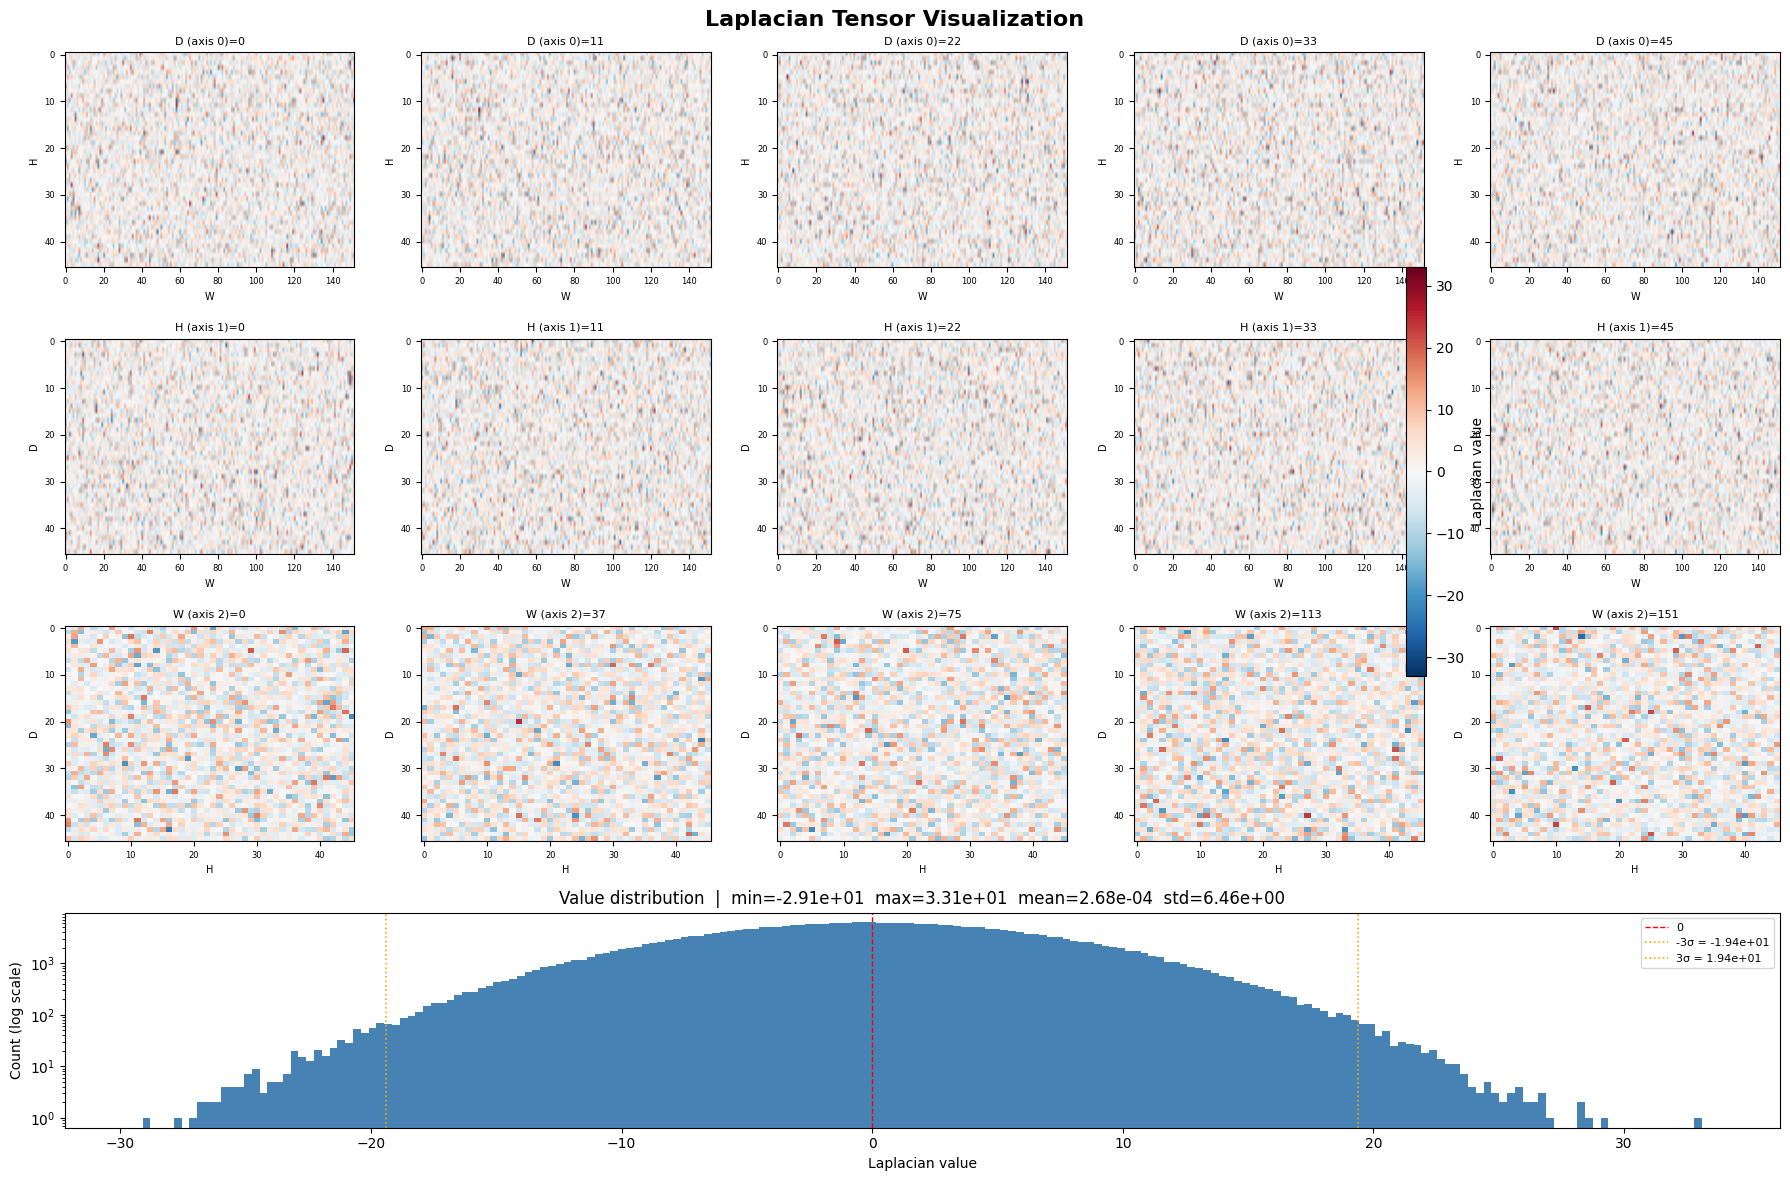

Saved → laplacian_plot.png


In [7]:
# --- Example usage ---
f  = torch.randn(46, 46, 152)          # replace with your actual tensor
lap = laplacian_3d_conv(f)             # or laplacian_3d_numerical(f)
plot_laplacian_3d(lap, n_slices=5)

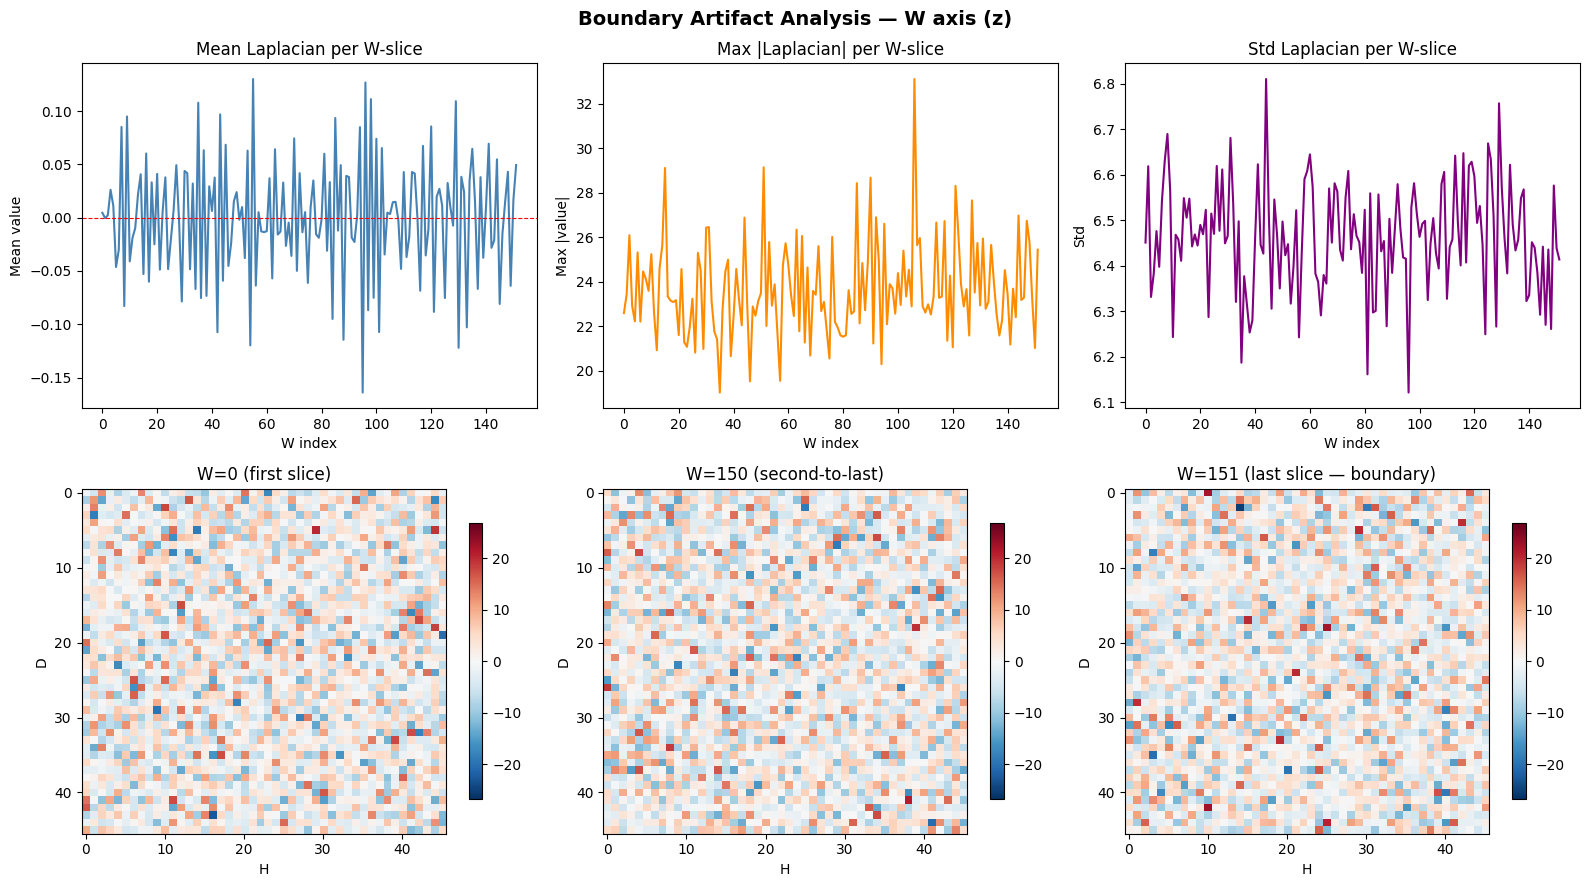

Saved → boundary_analysis.png
Interior  — mean: -8.841e-05  |  max|val|: 3.311e+01
Boundary W=0    — mean: 4.580e-03  |  max|val|: 2.260e+01
Boundary W=151 — mean: 4.939e-02  |  max|val|: 2.545e+01


In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_boundary_analysis(lap: torch.Tensor):
    """
    Focused analysis on the W-axis (z) boundary artifact.
    lap: shape (D, H, W)
    """
    data = lap.detach().cpu().numpy()
    D, H, W = data.shape

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("Boundary Artifact Analysis — W axis (z)", fontsize=14, fontweight="bold")

    # --- Row 1: Mean, Max abs, Std per W-slice ---
    w_indices = np.arange(W)
    mean_per_w   = data.mean(axis=(0, 1))           # shape (W,)
    maxabs_per_w = np.abs(data).max(axis=(0, 1))    # shape (W,)
    std_per_w    = data.std(axis=(0, 1))            # shape (W,)

    ax = axes[0, 0]
    ax.plot(w_indices, mean_per_w, color="steelblue")
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_title("Mean Laplacian per W-slice")
    ax.set_xlabel("W index")
    ax.set_ylabel("Mean value")

    ax = axes[0, 1]
    ax.plot(w_indices, maxabs_per_w, color="darkorange")
    ax.set_title("Max |Laplacian| per W-slice")
    ax.set_xlabel("W index")
    ax.set_ylabel("Max |value|")

    ax = axes[0, 2]
    ax.plot(w_indices, std_per_w, color="purple")
    ax.set_title("Std Laplacian per W-slice")
    ax.set_xlabel("W index")
    ax.set_ylabel("Std")

    # --- Row 2: Heatmaps of first, last, and second-to-last W-slices ---
    vmax = np.abs(data[:, :, -5:]).max()  # colormap driven by boundary region

    for col, (w_idx, label) in enumerate([
        (0,  "W=0 (first slice)"),
        (W-2, f"W={W-2} (second-to-last)"),
        (W-1, f"W={W-1} (last slice — boundary)"),
    ]):
        ax = axes[1, col]
        im = ax.imshow(data[:, :, w_idx], cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(label)
        ax.set_xlabel("H")
        ax.set_ylabel("D")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.savefig("boundary_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → boundary_analysis.png")

    # --- Print summary ---
    interior = data[:, :, 1:-1]  # strip boundary slices
    boundary_w0 = data[:, :, 0]
    boundary_w1 = data[:, :, -1]
    print(f"Interior  — mean: {interior.mean():.3e}  |  max|val|: {np.abs(interior).max():.3e}")
    print(f"Boundary W=0    — mean: {boundary_w0.mean():.3e}  |  max|val|: {np.abs(boundary_w0).max():.3e}")
    print(f"Boundary W={W-1} — mean: {boundary_w1.mean():.3e}  |  max|val|: {np.abs(boundary_w1).max():.3e}")


plot_boundary_analysis(lap)

In [30]:
lap = laplacian_3d_conv(torch.tensor(potential))

/tmp/ipykernel_376400/959147010.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


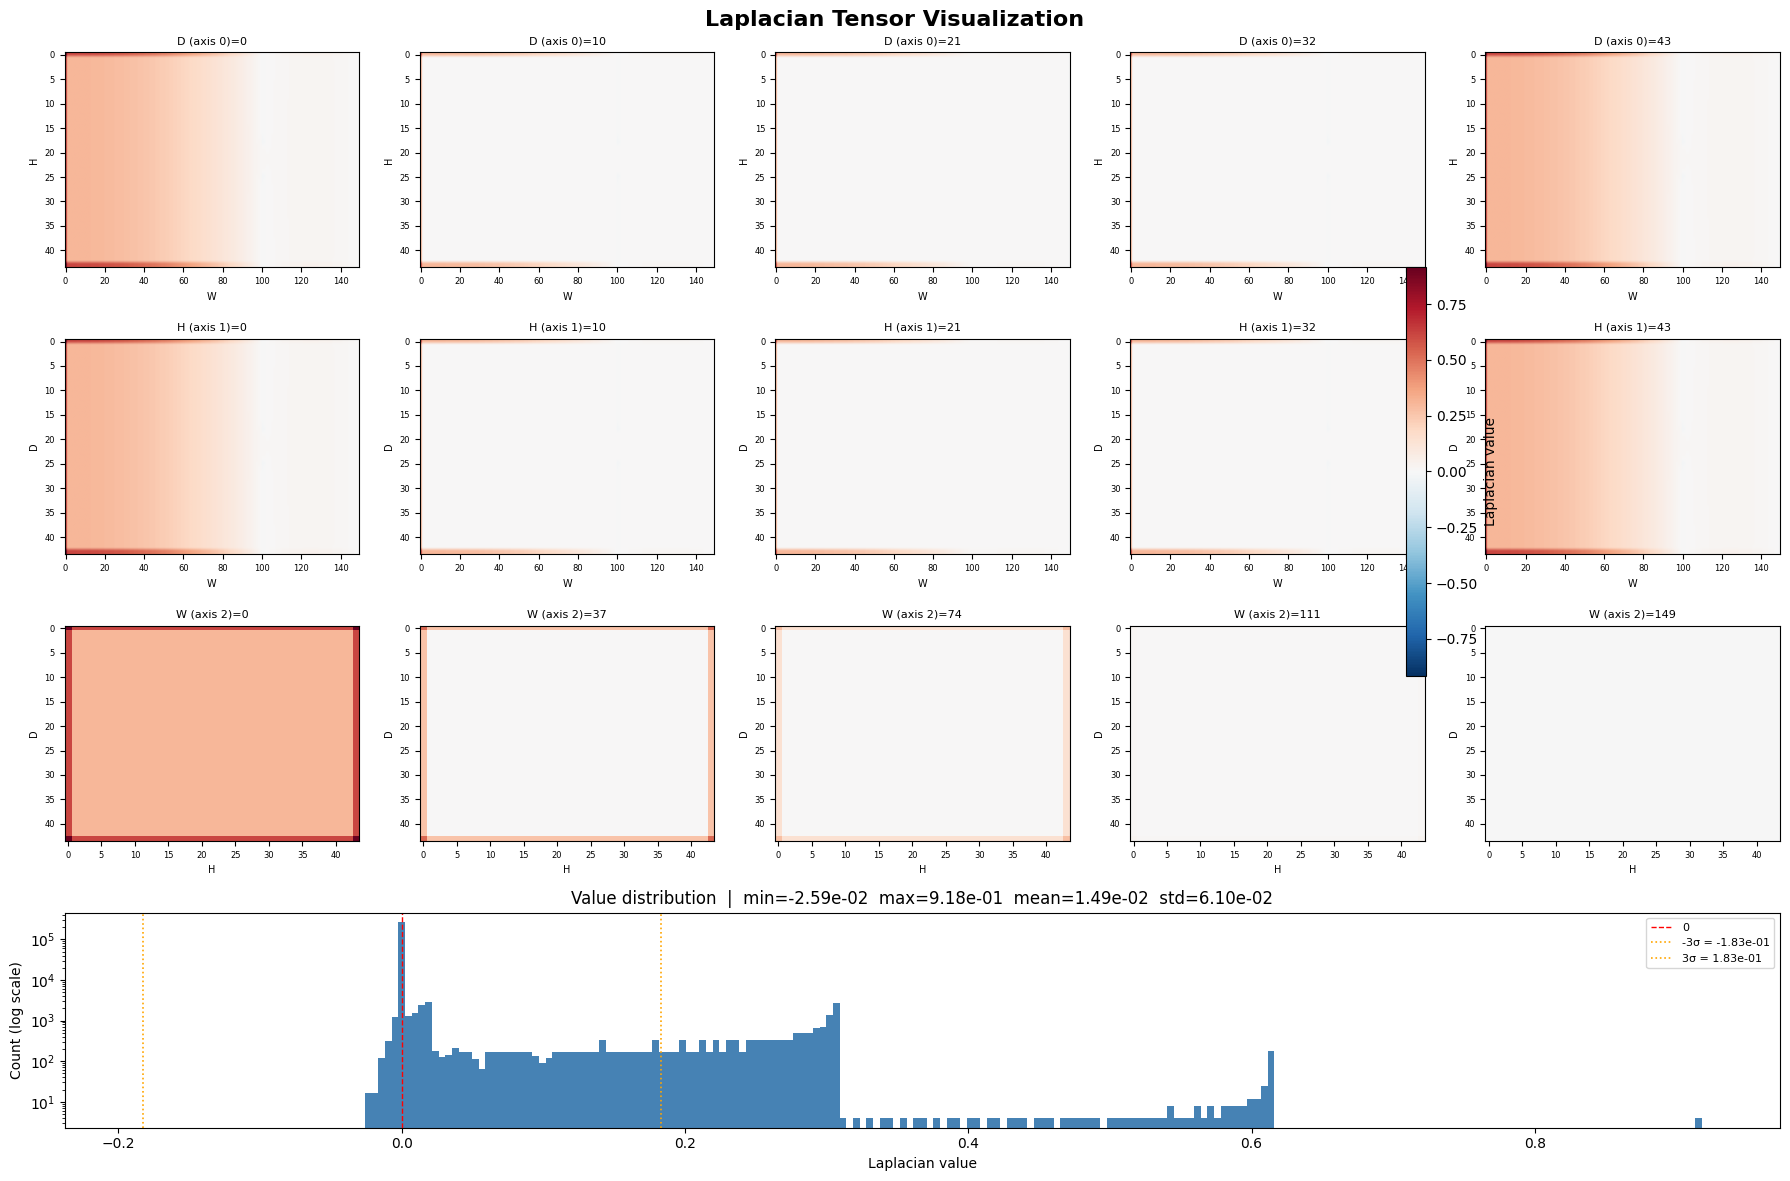

Saved → laplacian_plot.png


In [31]:
plot_laplacian_3d(lap, n_slices=5)

Solution δ   — max|δ|: 2.913e-03  std: 1.021e-03
∇²δ          : max|∇²δ|:   5.806e-03
Residual     : max|∇²δ + f|: 5.866e-03
Relative error:              9.776e+01  ❌ solver issue


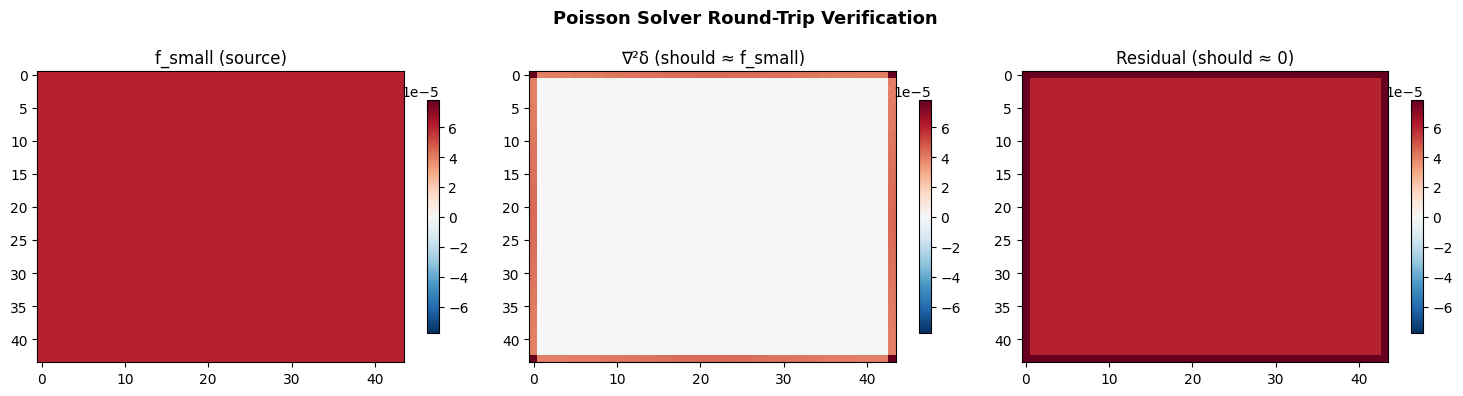

In [55]:
import torch
import matplotlib.pyplot as plt

def round_trip_test(potential, laplacian_fn, shape=(46, 46, 152), scale=1e-3):
    """
    fdm_solver:   your FDM Poisson solver, signature: solver(rhs) -> solution
    laplacian_fn: your laplacian function, signature: lap(tensor) -> tensor
    scale:        keep source term small to stay in the linear regime
    """

    # --- Step 1: build a small, smooth synthetic source term ---
    # Smooth is important — a random source would have its own boundary issues
    D, H, W = shape
    z = torch.linspace(0, 1, W)
    y = torch.linspace(0, 1, H)
    x = torch.linspace(0, 1, D)
    Z, Y, X = torch.meshgrid(z, y, x, indexing='ij')  # (W, H, D)
    X = X.permute(2, 1, 0)  # back to (D, H, W)
    Y = Y.permute(2, 1, 0)
    Z = Z.permute(2, 1, 0)

    # Simple smooth source: small amplitude sine wave, zero at boundaries
    # f_small = scale * torch.sin(torch.pi * X) * torch.sin(torch.pi * Y) * torch.sin(torch.pi * Z)
    # print(f"Source term  — max|f|: {f_small.abs().max():.3e}  std: {f_small.std():.3e}")
    f_small = 6*1e-5 * torch.ones(shape)
    # # --- Step 2: solve ∇²δ = f_small ---
    # delta = fdm_solver(f_small)
    delta = torch.tensor(potential)
    print(f"Solution δ   — max|δ|: {delta.abs().max():.3e}  std: {delta.std():.3e}")

    # --- Step 3: compute ∇²δ and compare to f_small ---
    lap_delta = laplacian_fn(delta)
    f_small = torch.ones_like(lap_delta) * 1e-5 * 6
    residual  = lap_delta + f_small
    rel_error = residual.abs().max() / (f_small.abs().max() + 1e-12)
    print(f"∇²δ          : max|∇²δ|:   {lap_delta.abs().max():.3e}")
    print(f"Residual     : max|∇²δ + f|: {residual.abs().max():.3e}")
    print(f"Relative error:              {rel_error:.3e}  {'✅ OK' if rel_error < 0.01 else '❌ solver issue'}")

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Poisson Solver Round-Trip Verification", fontsize=13, fontweight="bold")

    mid = W // 2
    vmax = max(f_small[:, :, mid].abs().max(), lap_delta[:, :, mid].abs().max()).item()

    for ax, data, title in zip(axes, 
        [f_small[:, :, mid], lap_delta[:, :, mid], residual[:, :, mid]],
        ["f_small (source)", "∇²δ (should ≈ f_small)", "Residual (should ≈ 0)"]
    ):
        im = ax.imshow(data.detach().numpy(), cmap="RdBu_r", 
                       vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.savefig("solver_verification.png", dpi=150, bbox_inches="tight")
    plt.show()

round_trip_test(potential, laplacian_3d_conv)